# 🚗 Drowsiness Detection — TRAIN

This notebook trains the CNN-LSTM-ViT drowsiness model.

**Resumable by design:**
- Run this notebook anytime. It checks `checkpoints/` for existing progress.
- If training is incomplete, it resumes from the last saved epoch.
- If training is already complete (reached `EPOCHS`), it skips training and just reports the final status.
- All checkpoints, the train/val/test split, logs, and metadata are saved to disk as training proceeds, so a crash, kernel restart, or Colab disconnect never costs you more than the current epoch.

Run cells top to bottom. No manual intervention needed.

## 1. Install & Imports

In [14]:
!pip install timm albumentations opencv-python scikit-learn pandas matplotlib seaborn tqdm


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import os
import json
import time
import shutil
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using:", device)

Using: cpu


## 2. Config

Everything that defines *what* is being trained lives here. Change these before a fresh run; once `checkpoints/` exists, the run resumes using the saved config (so don't change `BATCH_SIZE`/`SEQ_LEN`/model architecture mid-run — start a fresh `CHECKPOINT_DIR` instead if you need to).

In [17]:
# ---- Dataset paths (edit these for your machine) ----
NTHU_ROOT = r"D:\GECACS\Dissertation\datasets\NTHU\train"
MRL_TRAIN = r"D:\GECACS\Dissertation\datasets\MRL\data\train"
MRL_VAL   = r"D:\GECACS\Dissertation\datasets\MRL\data\val"
MRL_TEST  = r"D:\GECACS\Dissertation\datasets\MRL\data\test"

# ---- Hyperparameters ----
BATCH_SIZE = 4
SEQ_LEN    = 4
IMG_SIZE   = 224
EPOCHS     = 10
LR         = 1e-4

# ---- Storage ----
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

LAST_CKPT   = os.path.join(CHECKPOINT_DIR, "last.pth")       # full resumable state (model+optim+scaler+epoch)
BEST_CKPT   = os.path.join(CHECKPOINT_DIR, "best.pth")       # best model weights only (for inference)
META_FILE   = os.path.join(CHECKPOINT_DIR, "meta.json")      # training progress / bookkeeping
SPLIT_FILE  = os.path.join(CHECKPOINT_DIR, "data_split.csv") # frozen train/val/test split (so resuming uses the SAME split)
LOG_FILE    = os.path.join(CHECKPOINT_DIR, "training_log.csv")
REPORT_FILE = os.path.join(CHECKPOINT_DIR, "test_report.json")

print("Checkpoint directory:", os.path.abspath(CHECKPOINT_DIR))

Checkpoint directory: d:\GECACS\Dissertation\checkpoints


## 3. Build / Load the dataset index

If a frozen split already exists from a previous run, it's reloaded as-is so resumed training validates/tests on the exact same data. Otherwise it's built fresh from the dataset folders and saved immediately.

In [18]:
def gather_nthu(root):
    rows = []
    drowsy_path = os.path.join(root, "drowsy")
    for current_root, dirs, files in os.walk(drowsy_path):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                rows.append([os.path.join(current_root, file), 1])

    notdrowsy_path = os.path.join(root, "notdrowsy")
    for file in os.listdir(notdrowsy_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            rows.append([os.path.join(notdrowsy_path, file), 0])

    return rows


def gather_mrl(root):
    rows = []
    classes = [("awake", 0), ("sleepy", 1)]
    for class_name, label in classes:
        folder = os.path.join(root, class_name)
        if not os.path.exists(folder):
            continue
        for file in os.listdir(folder):
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                rows.append([os.path.join(folder, file), label])
    return rows

In [19]:
if os.path.exists(SPLIT_FILE):
    print("Found existing frozen split -> reusing it for consistent resume.")
    split_df = pd.read_csv(SPLIT_FILE)
    train_df = split_df[split_df["split"] == "train"].drop(columns=["split"])
    val_df   = split_df[split_df["split"] == "val"].drop(columns=["split"])
    test_df  = split_df[split_df["split"] == "test"].drop(columns=["split"])
else:
    print("No existing split found -> building dataset index from scratch.")
    rows = []
    rows += gather_nthu(NTHU_ROOT)
    rows += gather_mrl(MRL_TRAIN)
    rows += gather_mrl(MRL_VAL)
    rows += gather_mrl(MRL_TEST)

    df = pd.DataFrame(rows, columns=["path", "label"])
    print("Total Samples:", len(df))

    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df["label"], random_state=42
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
    )

    train_df = train_df.copy(); train_df["split"] = "train"
    val_df_s = val_df.copy();  val_df_s["split"] = "val"
    test_df_s = test_df.copy(); test_df_s["split"] = "test"
    pd.concat([train_df, val_df_s, test_df_s]).to_csv(SPLIT_FILE, index=False)
    train_df = train_df.drop(columns=["split"])

print(len(train_df), len(val_df), len(test_df))

Found existing frozen split -> reusing it for consistent resume.
105993 22713 22713


## 4. Dataset / DataLoaders

In [20]:
class DrowsinessDataset(Dataset):

    def __init__(self, dataframe, seq_len=SEQ_LEN, img_size=IMG_SIZE):
        self.df = dataframe.reset_index(drop=True)
        self.seq_len = seq_len
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.iloc[idx]["path"]
        label = self.df.iloc[idx]["label"]

        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(img)

        sequence = torch.stack([img] * self.seq_len)

        return sequence, torch.tensor(label, dtype=torch.long)

In [21]:
train_ds = DrowsinessDataset(train_df)
val_ds   = DrowsinessDataset(val_df)
test_ds  = DrowsinessDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

## 5. Model

In [22]:
class TemporalAttention(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, lstm_out):
        scores = self.attention(lstm_out)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * lstm_out, dim=1)
        return context

In [23]:
class CNN_LSTM_ViT(nn.Module):

    def __init__(self):
        super().__init__()

        mobilenet = torchvision.models.mobilenet_v3_large(
            weights=torchvision.models.MobileNet_V3_Large_Weights.DEFAULT
        )
        self.cnn = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        cnn_dim = 960

        self.lstm = nn.LSTM(
            input_size=cnn_dim, hidden_size=128, num_layers=2,
            batch_first=True, bidirectional=True, dropout=0.3,
        )

        self.attention = TemporalAttention(128)

        self.vit = timm.create_model("vit_tiny_patch16_224", pretrained=True, num_classes=0)
        vit_dim = 192

        self.classifier = nn.Sequential(
            nn.Linear(256 + vit_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        cnn_input = x.view(B * T, C, H, W)
        cnn_features = self.cnn(cnn_input)
        cnn_features = self.pool(cnn_features).flatten(1)
        cnn_features = cnn_features.view(B, T, -1)

        lstm_out, _ = self.lstm(cnn_features)
        temporal_features = self.attention(lstm_out)

        last_frame = x[:, -1]
        vit_features = self.vit(last_frame)

        fusion = torch.cat([temporal_features, vit_features], dim=1)
        output = self.classifier(fusion)
        return output

## 6. Resume logic

Loads `last.pth` if it exists (model, optimizer, scaler, epoch reached, best accuracy so far). If nothing exists yet, starts completely fresh.

In [24]:
model = CNN_LSTM_ViT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler()

start_epoch = 0
best_acc = 0.0

if os.path.exists(LAST_CKPT):
    print(f"Found existing checkpoint: {LAST_CKPT} -> resuming.")
    ckpt = torch.load(LAST_CKPT, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scaler.load_state_dict(ckpt["scaler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_acc = ckpt.get("best_acc", 0.0)
    print(f"Resuming from epoch {start_epoch} (already completed {ckpt['epoch']+1}/{EPOCHS}). Best val acc so far: {best_acc:.4f}")
else:
    print("No checkpoint found -> starting fresh training.")

if os.path.exists(META_FILE):
    with open(META_FILE) as f:
        meta = json.load(f)
else:
    meta = {"epochs_completed": 0, "total_epochs": EPOCHS, "best_acc": 0.0, "status": "not_started"}

C:\Users\irg\AppData\Local\Temp\ipykernel_10480\3024116116.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
d:\GECACS\Dissertation\venv\Lib\site-packages\torch\cuda\amp\grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


Found existing checkpoint: checkpoints\last.pth -> resuming.
Resuming from epoch 8 (already completed 8/10). Best val acc so far: 0.9878


## 7. Train / Validate functions

In [25]:
def train_one_epoch():
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc="train"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return train_loss / max(1, len(train_loader)), correct / total


def validate():
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            pred = outputs.argmax(1)
            preds.extend(pred.cpu().numpy())
            labels_all.extend(labels.numpy())

    return accuracy_score(labels_all, preds)

## 8. Train loop (resumable, checkpointed every epoch)

If training already reached `EPOCHS`, this cell skips straight to reporting — it will NOT retrain from scratch.

In [26]:
if start_epoch >= EPOCHS:
    print(f"Training already complete: {start_epoch}/{EPOCHS} epochs done. Skipping training.")
    print(f"Best validation accuracy: {best_acc:.4f}")
else:
    print(f"Training epochs {start_epoch+1} to {EPOCHS}...")

    for epoch in range(start_epoch, EPOCHS):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch()
        val_acc = validate()
        dt = time.time() - t0

        print(f"Epoch {epoch+1}/{EPOCHS} | loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | {dt:.1f}s")

        is_best = val_acc > best_acc
        if is_best:
            best_acc = val_acc

        # --- Save resumable full checkpoint (always, every epoch) ---
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scaler_state": scaler.state_dict(),
            "best_acc": best_acc,
            "val_acc": val_acc,
            "train_acc": train_acc,
            "train_loss": train_loss,
        }, LAST_CKPT)

        # --- Save best-only weights (for the Run notebook) ---
        if is_best:
            torch.save(model.state_dict(), BEST_CKPT)
            print(f"  -> New best model saved (val_acc={val_acc:.4f})")

        # --- Update metadata ---
        meta = {
            "epochs_completed": epoch + 1,
            "total_epochs": EPOCHS,
            "best_acc": best_acc,
            "last_val_acc": val_acc,
            "status": "complete" if epoch + 1 == EPOCHS else "in_progress",
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        }
        with open(META_FILE, "w") as f:
            json.dump(meta, f, indent=2)

        # --- Append to training log CSV ---
        log_row = pd.DataFrame([{
            "epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc,
            "val_acc": val_acc, "is_best": is_best, "time_sec": dt,
        }])
        if os.path.exists(LOG_FILE):
            log_row.to_csv(LOG_FILE, mode="a", header=False, index=False)
        else:
            log_row.to_csv(LOG_FILE, index=False)

    print("Training complete.")
    print(f"Best validation accuracy: {best_acc:.4f}")

Training epochs 9 to 10...


train:   0%|          | 0/26499 [00:00<?, ?it/s]

C:\Users\irg\AppData\Local\Temp\ipykernel_10480\2359104521.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
d:\GECACS\Dissertation\venv\Lib\site-packages\torch\cuda\amp\autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
train: 100%|██████████| 26499/26499 [15:19:57<00:00,  2.08s/it]   


Epoch 9/10 | loss=0.0252 | train_acc=0.9912 | val_acc=0.9861 | 59433.4s


train:   0%|          | 0/26499 [00:00<?, ?it/s]C:\Users\irg\AppData\Local\Temp\ipykernel_10480\2359104521.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
d:\GECACS\Dissertation\venv\Lib\site-packages\torch\cuda\amp\autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
train: 100%|██████████| 26499/26499 [15:23:31<00:00,  2.09s/it]  


Epoch 10/10 | loss=0.0239 | train_acc=0.9920 | val_acc=0.9903 | 59716.8s
  -> New best model saved (val_acc=0.9903)
Training complete.
Best validation accuracy: 0.9903


## 9. Final test-set evaluation

Runs on the held-out test split using the **best** checkpoint (not just whatever's left in memory), and saves a report to disk.

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     11017
           1       0.99      0.99      0.99     11696

    accuracy                           0.99     22713
   macro avg       0.99      0.99      0.99     22713
weighted avg       0.99      0.99      0.99     22713



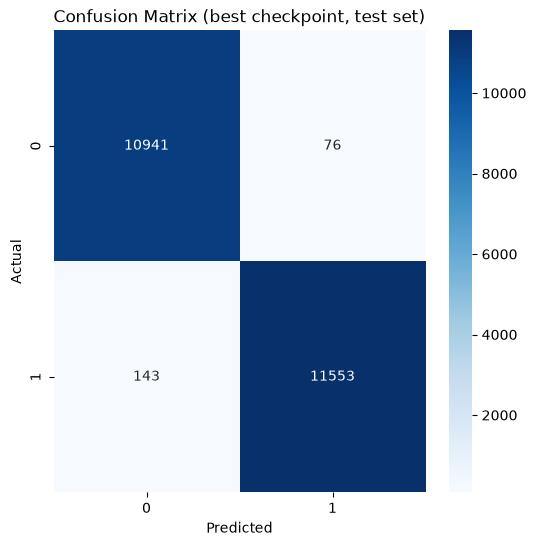

In [27]:
eval_model = CNN_LSTM_ViT().to(device)
eval_model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
eval_model.eval()

preds, targets = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = eval_model(images)
        pred = outputs.argmax(1)
        preds.extend(pred.cpu().numpy())
        targets.extend(labels.numpy())

report_text = classification_report(targets, preds)
report_dict = classification_report(targets, preds, output_dict=True)
print(report_text)

with open(REPORT_FILE, "w") as f:
    json.dump(report_dict, f, indent=2)

cm = confusion_matrix(targets, preds)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (best checkpoint, test set)")
plt.savefig(os.path.join(CHECKPOINT_DIR, "confusion_matrix.png"))
plt.show()

## Done

Files now in `checkpoints/`:
- `last.pth` — full resumable training state (model + optimizer + scaler + epoch)
- `best.pth` — best-performing model weights (used by the Run notebook)
- `meta.json` — training progress summary
- `data_split.csv` — frozen dataset split
- `training_log.csv` — per-epoch metrics
- `test_report.json`, `confusion_matrix.png` — final evaluation artifacts

Open **02_Run.ipynb** to use the trained model for live webcam inference.